# MAE — UMAP Visualization of Patch Embeddings (z_i)

**Model:** `facebook/vit-mae-large` (ViT-L/16)  
**Dataset:** ImageNette (10 classes, val split)

---

Two questions to answer:

1. **Global semantics**: Are z_i embeddings from patches of the **same class** close in UMAP space?  
2. **Spatial structure**: Do z_i embeddings cluster by **spatial position** (quadrant)?

---
## 1. Setup

In [4]:
import os
import types
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from transformers import ViTMAEModel, ViTImageProcessor
import umap

print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {__import__('transformers').__version__}")
print(f"Device       : {'cuda' if torch.cuda.is_available() else 'cpu'}")

c:\Users\PC\Desktop\Computer Vision\Computer-Vision\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch      : 2.12.0+cpu
Transformers : 5.8.1
Device       : cpu


In [5]:
MAE_PATH = './vit-mae-large' if os.path.exists('./vit-mae-large') else 'facebook/vit-mae-large'

# Auto-download ImageNette if not found locally
_inet_path = None
for _candidate in ['./imagenette/val', './imagenette2-320/val', './imagenette2/val']:
    if os.path.exists(_candidate):
        _inet_path = _candidate
        break
if _inet_path is None:
    import urllib.request, tarfile
    print('Downloading ImageNette (~1.5 GB)...')
    urllib.request.urlretrieve(
        'https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz',
        'imagenette2-320.tgz')
    with tarfile.open('imagenette2-320.tgz') as _tar:
        _tar.extractall('.')
    os.remove('imagenette2-320.tgz')
    _inet_path = './imagenette2-320/val'
    print('Done.')

DATASET_PATH = _inet_path

# Extraction parameters
N_IMAGES_PER_CLASS = 50
IMAGE_SIZE         = 224
RANDOM_STATE       = 42

# UMAP parameters
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.1
UMAP_METRIC      = "cosine"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = {
    'n01440764': 'tench',
    'n02102040': 'English springer',
    'n02979186': 'cassette player',
    'n03000684': 'chain saw',
    'n03028079': 'church',
    'n03394916': 'French horn',
    'n03417042': 'garbage truck',
    'n03425413': 'gas pump',
    'n03445777': 'golf ball',
    'n03888257': 'parachute'
}

CLASS_COLORS    = sns.color_palette("tab10", 10)
QUADRANT_NAMES  = ["top-left", "top-right", "bottom-left", "bottom-right"]
QUADRANT_COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

os.makedirs("figures", exist_ok=True)

---
## 2. Model and dataset loading

In [6]:
import warnings
# prépare les images (resize + normalisation)
processor = ViTImageProcessor(
    size={"height": 224, "width": 224},
    image_mean=[0.485, 0.456, 0.406],
    image_std=[0.229, 0.224, 0.225],
)

# Modèle MAE — on supprime les warnings sur les clés du décodeur :
# ViTMAEModel charge uniquement l'encodeur, les clés du décodeur sont
# présentes dans le checkpoint mais non utilisées → UNEXPECTED attendu.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = ViTMAEModel.from_pretrained(MAE_PATH)

model.eval()
model.to(DEVICE)

PATCH_SIZE = model.config.patch_size        # 16
GRID_SIZE  = IMAGE_SIZE // PATCH_SIZE       # 14
N_PATCHES  = GRID_SIZE * GRID_SIZE          # 196
HIDDEN_DIM = model.config.hidden_size       # 1024

print(f"Modèle chargé")
print(f"  patch_size = {PATCH_SIZE}  ->  grille {GRID_SIZE}x{GRID_SIZE} = {N_PATCHES} patches")
print(f"  hidden_dim = {HIDDEN_DIM}")

Loading weights: 100%|██████████| 390/390 [00:00<00:00, 9110.69it/s]
[transformers] ViTMAEModel LOAD REPORT from: vit-mae-large
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_pos_embed                                                        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.bias       

Modèle chargé
  patch_size = 16  ->  grille 14x14 = 196 patches
  hidden_dim = 1024


In [7]:
# Dataset ImageNette
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])

dataset = ImageFolder(root=DATASET_PATH, transform=transform)
class_names_list = [CLASS_NAMES.get(c, c) for c in dataset.classes]

print(f"Classes : {class_names_list}")
print(f"Nombre d'images : {len(dataset)}")

# Sous-échantillonnage équilibré : N_IMAGES_PER_CLASS par classe
targets = np.array(dataset.targets)
selected_indices = []

for class_idx in range(len(dataset.classes)):
    idx    = np.where(targets == class_idx)[0]
    chosen = np.random.default_rng(RANDOM_STATE).choice(
        idx, size=min(N_IMAGES_PER_CLASS, len(idx)), replace=False
    ).tolist()
    selected_indices.extend(chosen)

print(f"-> {len(selected_indices)} images selectionnees ({N_IMAGES_PER_CLASS}/classe)")

Classes : ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']
Nombre d'images : 3925
-> 500 images selectionnees (50/classe)


---
## 3. Main analysis — z_i of individual patches

For each image, masking is disabled and **all 196 patches** are passed through the encoder.  
The output `last_hidden_state` has shape `(1, 197, 1024)`:
- position 0 = CLS token → set aside for section 5
- positions 1 to 196 = **z_i of each patch** → analyzed here

> **Why disable masking?**  
> Without disabling, the encoder only sees 49 patches/image (25%) drawn randomly —  
> position analysis would be impossible and z_i would not be comparable across images.

In [ ]:
# Désactivation du masquage via monkey-patch
def no_masking(self, sequence, noise=None):
    batch_size, seq_length, dim = sequence.shape
    mask        = torch.zeros(batch_size, seq_length, device=sequence.device)
    ids_restore = torch.arange(seq_length, device=sequence.device).unsqueeze(0).repeat(batch_size, 1)
    return sequence, mask, ids_restore

model.embeddings.random_masking = types.MethodType(no_masking, model.embeddings)

# Vérification doit afficher 196
image_pil, _ = dataset[0]
inputs = processor(images=image_pil, return_tensors="pt")
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
with torch.no_grad():
    test_out = model(**inputs)
print(f"Patches visibles : {test_out.last_hidden_state.shape[1] - 1}")  # doit être 196

Patches visibles : 196


In [ ]:
# Extraction des z_i pour toutes les images sélectionnées
@torch.no_grad()
def extract_patch_embeddings(dataset, indices):
    all_z, all_labels, all_patch_ids = [], [], []

    for i in tqdm(indices, desc="Extraction z_i"):
        image_pil, class_idx = dataset[i]
        inputs  = processor(images=image_pil, return_tensors="pt")
        inputs  = {k: v.to(DEVICE) for k, v in inputs.items()}
        outputs = model(**inputs)

        z = outputs.last_hidden_state[0, 1:].cpu().numpy()  # (196, 1024) on retire le CLS

        all_z.append(z)
        all_labels.append(np.full(z.shape[0], class_idx))
        all_patch_ids.append(np.arange(z.shape[0]))

    return (
        np.concatenate(all_z, axis=0),
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_patch_ids, axis=0),
    )


all_z, all_labels, all_patch_ids = extract_patch_embeddings(dataset, selected_indices)

print(f"all_z        : {all_z.shape}")          # (98000, 1024)
print(f"all_labels   : {all_labels.shape}")     # (98000,)
print(f"all_patch_ids: {all_patch_ids.shape}")  # (98000,)

Extraction z_i: 100%|██████████| 500/500 [19:28<00:00,  2.34s/it]


all_z        : (98000, 1024)
all_labels   : (98000,)
all_patch_ids: (98000,)


In [7]:
# UMAP sur les 98 000 z_i
print(f"UMAP sur {all_z.shape[0]:,} points x {all_z.shape[1]} dimensions...")

reducer = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    n_components=2,
    random_state=RANDOM_STATE,
    verbose=True
)
embedding = reducer.fit_transform(all_z)
print(f"Projection terminée : {embedding.shape}")

UMAP sur 98,000 points x 1024 dimensions...


c:\Users\PC\Desktop\Computer Vision\Computer-Vision\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Fri May 22 04:34:11 2026 Construct fuzzy simplicial set
Fri May 22 04:34:12 2026 Finding Nearest Neighbors
Fri May 22 04:34:12 2026 Building RP forest with 21 trees
Fri May 22 04:35:01 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	Stopping threshold met -- exiting after 4 iterations
Fri May 22 04:39:03 2026 Finished Nearest Neighbor Search
Fri May 22 04:39:17 2026 Construct embedding


Epochs completed:   0%|            1/200 [00:04]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [07:06]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [07:45]


Fri May 22 04:47:26 2026 Finished embedding
Projection terminée : (98000, 2)


In [8]:
# Calcul du quadrant de chaque patch (grille 14×14 divisée en 4)
# 0=haut-gauche  1=haut-droit  2=bas-gauche  3=bas-droit
def patch_id_to_quadrant(patch_ids, grid_size=GRID_SIZE):
    rows = patch_ids // grid_size
    cols = patch_ids %  grid_size
    half = grid_size // 2  # = 7
    return (rows >= half).astype(int) * 2 + (cols >= half).astype(int)

all_quadrants = patch_id_to_quadrant(all_patch_ids)

for q, name in enumerate(QUADRANT_NAMES):
    pct = (all_quadrants == q).mean() * 100
    print(f"  Quadrant {q} ({name:12s}) : {pct:.1f}%")  # ~25% chacun

  Quadrant 0 (haut-gauche ) : 25.0%
  Quadrant 1 (haut-droit  ) : 25.0%
  Quadrant 2 (bas-gauche  ) : 25.0%
  Quadrant 3 (bas-droit   ) : 25.0%


### 3.1 — UMAP colored by class

Each point is a z_i. Color indicates the class of its source image.

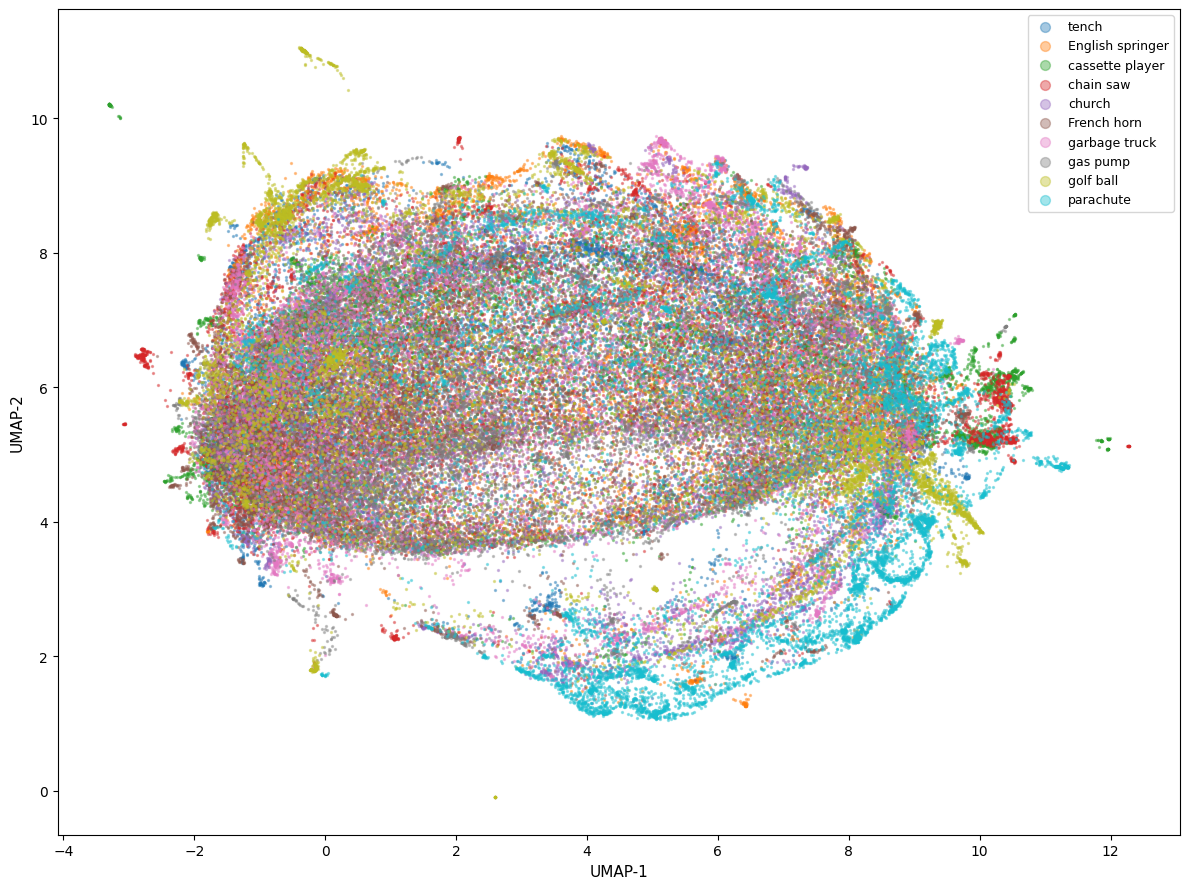

In [25]:
fig, ax = plt.subplots(figsize=(12, 9))

for class_idx in range(len(dataset.classes)):
    mask = all_labels == class_idx
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=[CLASS_COLORS[class_idx]], s=2, alpha=0.4,
        label=class_names_list[class_idx], rasterized=True
    )

ax.set_xlabel("UMAP-1", fontsize=11)
ax.set_ylabel("UMAP-2", fontsize=11)
ax.legend(markerscale=5, fontsize=9, loc="upper right", framealpha=0.8)
plt.tight_layout()
plt.savefig("figures/umap_patches_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 — Spatial visualization: Color by position (quadrant)

Is the spatial position of a patch encoded in its z_i?

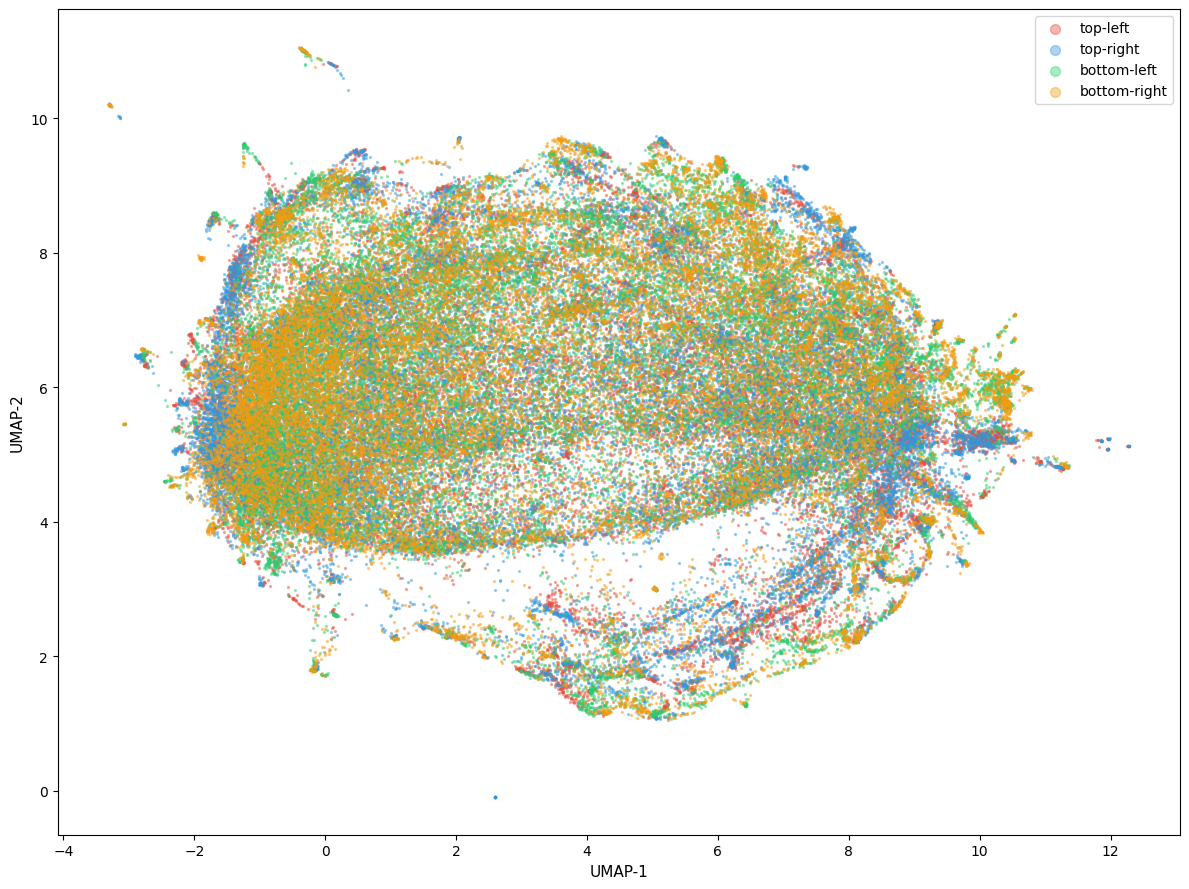

In [24]:
fig, ax = plt.subplots(figsize=(12, 9))

for q_idx, (name, color) in enumerate(zip(QUADRANT_NAMES, QUADRANT_COLORS)):
    mask = all_quadrants == q_idx
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=color, s=2, alpha=0.4,
        label=name, rasterized=True
    )

ax.set_xlabel("UMAP-1", fontsize=11)
ax.set_ylabel("UMAP-2", fontsize=11)
ax.legend(markerscale=5, fontsize=10, loc="upper right", framealpha=0.8)
plt.tight_layout()
plt.savefig("figures/umap_patches_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 — Combined view

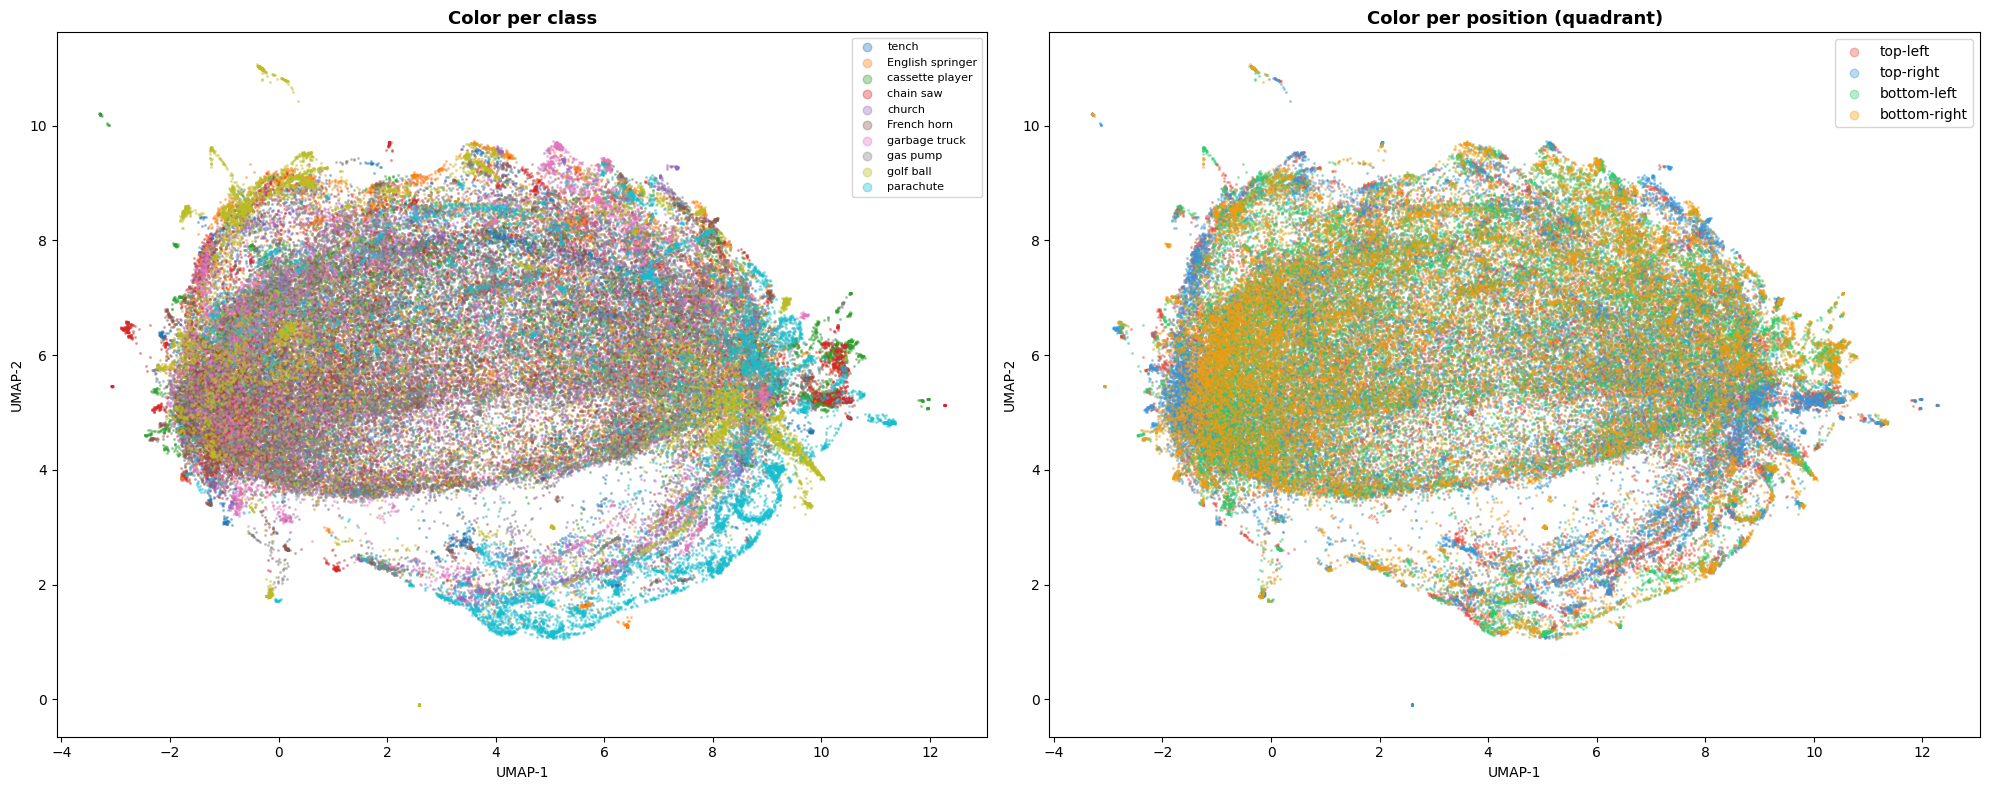

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gauche : par classe
ax = axes[0]
for class_idx in range(len(dataset.classes)):
    mask = all_labels == class_idx
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=[CLASS_COLORS[class_idx]], s=1.5, alpha=0.35,
        label=class_names_list[class_idx], rasterized=True
    )
ax.set_title("Color per class", fontsize=13, fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=5, fontsize=8, loc="upper right", framealpha=0.8)

# Droite : par quadrant
ax = axes[1]
for q_idx, (name, color) in enumerate(zip(QUADRANT_NAMES, QUADRANT_COLORS)):
    mask = all_quadrants == q_idx
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=color, s=1.5, alpha=0.35,
        label=name, rasterized=True
    )
ax.set_title("Color per position (quadrant)", fontsize=13, fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=5, fontsize=10, loc="upper right", framealpha=0.8)

plt.tight_layout()
plt.savefig("figures/umap_patches_combined.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Complementary analysis — Mean z_i per image

Instead of looking at 196 z_i individually, we compute their **mean** to obtain a single vector per image.

In [26]:
# Reshape (98000, 1024) -> (500, 196, 1024) puis moyenne sur les patches
n_images = len(selected_indices)  # 500

all_z_mean      = all_z.reshape(n_images, N_PATCHES, 1024).mean(axis=1)
all_labels_mean = all_labels.reshape(n_images, N_PATCHES)[:, 0].astype(int)

print(f"all_z_mean      : {all_z_mean.shape}")      # (500, 1024)
print(f"all_labels_mean : {all_labels_mean.shape}") # (500,)

all_z_mean      : (500, 1024)
all_labels_mean : (500,)


In [27]:
reducer_mean   = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=RANDOM_STATE)
embedding_mean = reducer_mean.fit_transform(all_z_mean)
print(f"Projection : {embedding_mean.shape}")  # (500, 2)

c:\Users\PC\Desktop\Computer Vision\Computer-Vision\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Projection : (500, 2)


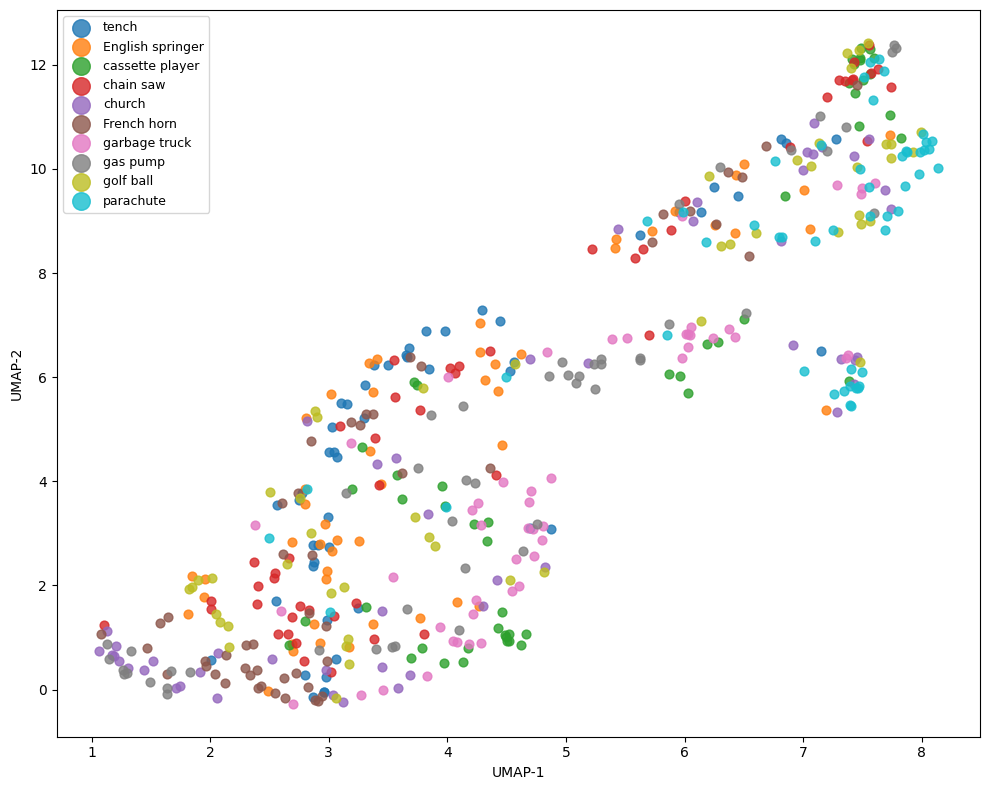

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))

for class_idx in range(len(dataset.classes)):
    mask = all_labels_mean == class_idx
    ax.scatter(
        embedding_mean[mask, 0], embedding_mean[mask, 1],
        c=[CLASS_COLORS[class_idx]], s=40, alpha=0.8,
        label=class_names_list[class_idx]
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("figures/umap_mean_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. CLS token without masking

The **CLS token** (position 0 in `last_hidden_state`) aggregates information from all patches  
via the self-attention mechanism over 24 Transformer layers.  
It is the model's image-level representation — used here as a reference to measure  
how far individual z_i are from a semantically rich representation.

In [14]:
@torch.no_grad()
def extract_cls_embeddings(dataset, indices):
    all_z_cls  = []
    all_labels_cls = []

    for i in tqdm(indices, desc="Extraction CLS"):
        image_pil, class_idx = dataset[i]
        inputs  = processor(images=image_pil, return_tensors="pt")
        inputs  = {k: v.to(DEVICE) for k, v in inputs.items()}
        outputs = model(**inputs)  # masquage déjà désactivé

        cls_token = outputs.last_hidden_state[0, 0].cpu().numpy()  # (1024,)
        all_z_cls.append(cls_token)
        all_labels_cls.append(class_idx)

    return np.array(all_z_cls), np.array(all_labels_cls)


all_z_cls, all_labels_cls = extract_cls_embeddings(dataset, selected_indices)
print(f"all_z_cls  : {all_z_cls.shape}")      # (500, 1024)
print(f"all_labels : {all_labels_cls.shape}") # (500,)

Extraction CLS: 100%|██████████| 500/500 [21:04<00:00,  2.53s/it]

all_z_cls  : (500, 1024)
all_labels : (500,)


In [15]:
reducer_cls   = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=RANDOM_STATE)
embedding_cls = reducer_cls.fit_transform(all_z_cls)
print(f"Projection : {embedding_cls.shape}")  # (500, 2)

c:\Users\PC\Desktop\Computer Vision\Computer-Vision\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Projection : (500, 2)


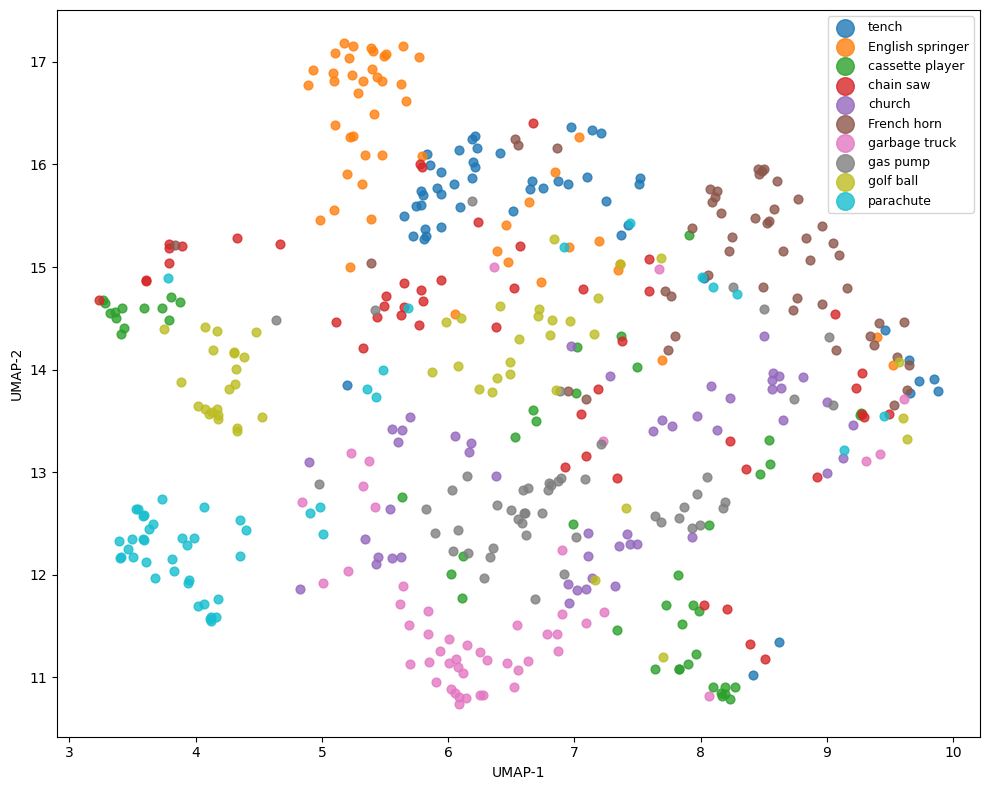

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

for class_idx in range(len(dataset.classes)):
    mask = all_labels_cls == class_idx
    ax.scatter(
        embedding_cls[mask, 0], embedding_cls[mask, 1],
        c=[CLASS_COLORS[class_idx]], s=40, alpha=0.8,
        label=class_names_list[class_idx]
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("figures/umap_cls_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Center vs Borders

Patches from the **center** of an image generally capture the main subject,  
while **border** patches mostly contain background.  
→ We test whether center z_i show better class separation than border ones,  
which would indicate that semantic information is not uniformly distributed across patches.

In [17]:
# Définition des régions sur la grille 14×14
rows_all = all_patch_ids // GRID_SIZE
cols_all = all_patch_ids %  GRID_SIZE

# Centre : lignes 4-9, colonnes 4-9 (36 patches / 196)
mask_centre = (
    (rows_all >= 4) & (rows_all <= 9) &
    (cols_all >= 4) & (cols_all <= 9)
)
# Bords : tout ce qui n'est pas dans le centre
mask_bords = ~mask_centre

print(f"Total patches  : {len(all_patch_ids):,}")
print(f"Patches centre : {mask_centre.sum():,}  ({mask_centre.mean()*100:.1f}%)")
print(f"Patches bords  : {mask_bords.sum():,}  ({mask_bords.mean()*100:.1f}%)")

Total patches  : 98,000
Patches centre : 18,000  (18.4%)
Patches bords  : 80,000  (81.6%)


UMAP centre : 18,000 points...


c:\Users\PC\Desktop\Computer Vision\Computer-Vision\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


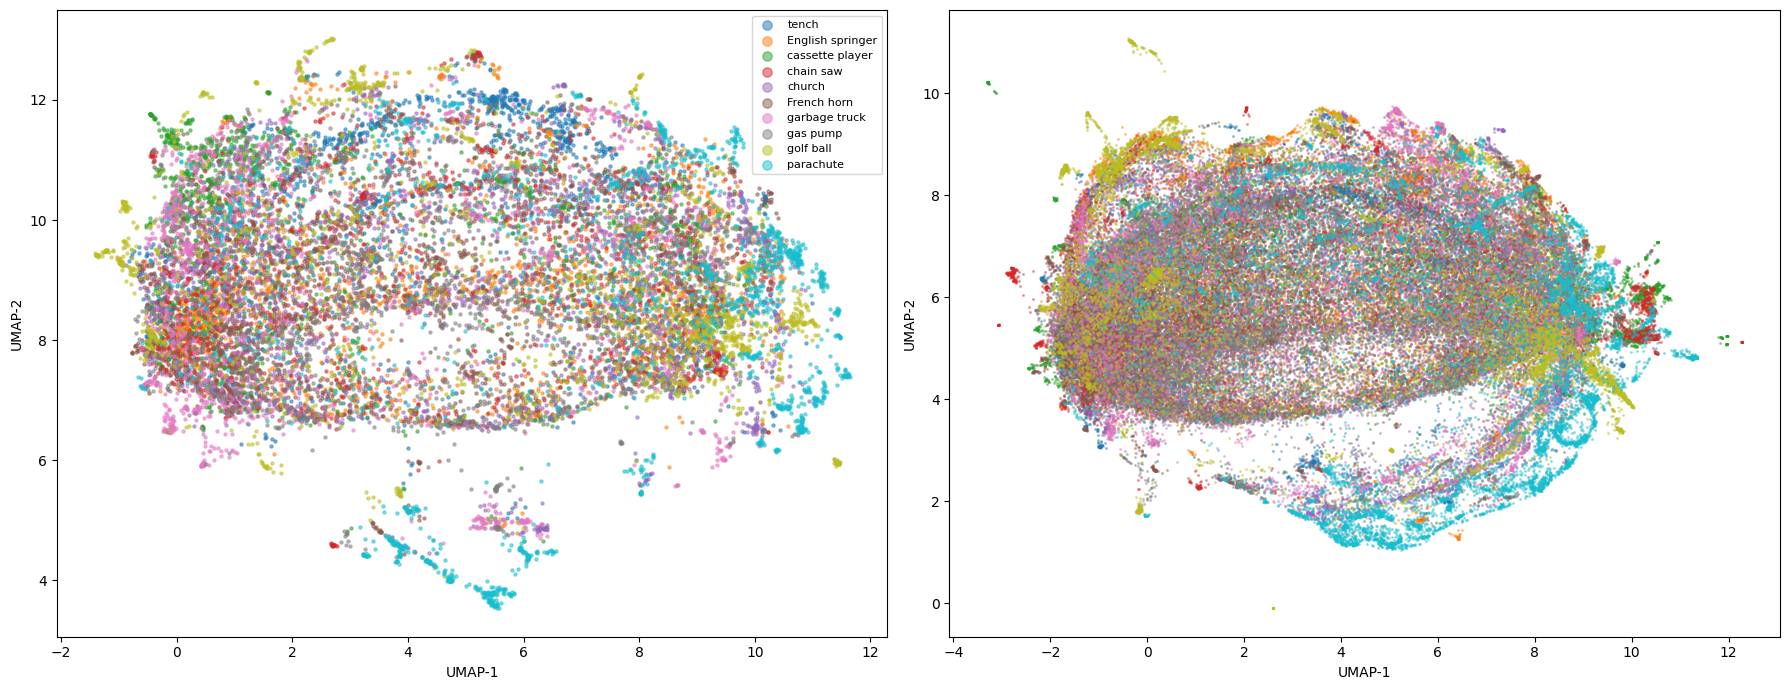

In [ ]:
# UMAP dédié sur les patches du centre uniquement
# (recalculé from scratch pour ne pas être influencé par la géométrie des bords)
print(f"UMAP centre : {mask_centre.sum():,} points...")
reducer_centre   = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=RANDOM_STATE)
embedding_centre = reducer_centre.fit_transform(all_z[mask_centre])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gauche  patches du centre, UMAP dédié
ax = axes[0]
for class_idx in range(len(dataset.classes)):
    mask_class = all_labels[mask_centre] == class_idx
    ax.scatter(
        embedding_centre[mask_class, 0],
        embedding_centre[mask_class, 1],
        c=[CLASS_COLORS[class_idx]], s=5, alpha=0.5,
        label=class_names_list[class_idx], rasterized=True
    )
    
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=3, fontsize=8, loc="upper right", framealpha=0.8)

# Droite tous les patches (rappel depuis l'embedding global)
ax = axes[1]
for class_idx in range(len(dataset.classes)):
    mask_class = all_labels == class_idx
    ax.scatter(
        embedding[mask_class, 0], embedding[mask_class, 1],
        c=[CLASS_COLORS[class_idx]], s=1.5, alpha=0.35,
        label=class_names_list[class_idx], rasterized=True
    )

ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

plt.tight_layout()
plt.savefig("figures/umap_centre_vs_all.png", dpi=150, bbox_inches="tight")
plt.show()

### 7 — CLS token with 75% masking

Here we re-enable the original MAE masking (75% of patches hidden).
The encoder only sees 49 random visible patches, and the CLS token
must summarize the image from this partial information.

**Interest:** Compare CLS with and without masking

In [8]:
model_masked = ViTMAEModel.from_pretrained(MAE_PATH)
model_masked.eval()
model_masked.to(DEVICE)
print("model_masked chargé")

Loading weights: 100%|██████████| 390/390 [00:00<00:00, 5070.03it/s]
[transformers] ViTMAEModel LOAD REPORT from: vit-mae-large
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_pos_embed                                                        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.bias       

model_masked chargé


In [9]:
@torch.no_grad()
def extract_cls_masked_quick(dataset, indices, n_seeds=5):
    all_z_cls_m  = []
    all_labels_m = []

    for i in tqdm(indices, desc="CLS masqué"):
        image_pil, class_idx = dataset[i]
        inputs = processor(images=image_pil, return_tensors="pt")
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        # Moyenne sur plusieurs tirages de masquage pour stabiliser le CLS
        cls_draws = []
        for s in range(n_seeds):
            generator = torch.Generator().manual_seed(42 + s)
            noise     = torch.rand(1, 196, generator=generator).to(DEVICE)
            outputs   = model_masked(pixel_values=inputs["pixel_values"], noise=noise)
            cls_draws.append(outputs.last_hidden_state[0, 0])

        cls = torch.stack(cls_draws, dim=0).mean(dim=0).cpu().numpy()

        all_z_cls_m.append(cls)
        all_labels_m.append(class_idx)

    return np.array(all_z_cls_m), np.array(all_labels_m)

In [ ]:
# Sous-échantillonnage rapide : 20 images/classe
small_indices = []
for class_idx in range(len(dataset.classes)):
    idx    = np.where(targets == class_idx)[0]
    chosen = np.random.default_rng(0).choice(idx, size=20, replace=False).tolist()
    small_indices.extend(chosen)

all_z_cls_m, all_labels_cls_m = extract_cls_masked_quick(dataset, small_indices)
print(all_z_cls_m.shape)  # (200, 1024)

CLS masqué:   0%|          | 0/200 [00:00<?, ?it/s]

CLS masqué: 100%|██████████| 200/200 [13:34<00:00,  4.07s/it]

(200, 1024)


In [11]:
reducer_cls_m   = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=RANDOM_STATE)
embedding_cls_m = reducer_cls_m.fit_transform(all_z_cls_m)
print(f"Projection : {embedding_cls_m.shape}")  # (500, 2)

c:\Users\PC\Desktop\Computer Vision\Computer-Vision\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Projection : (200, 2)


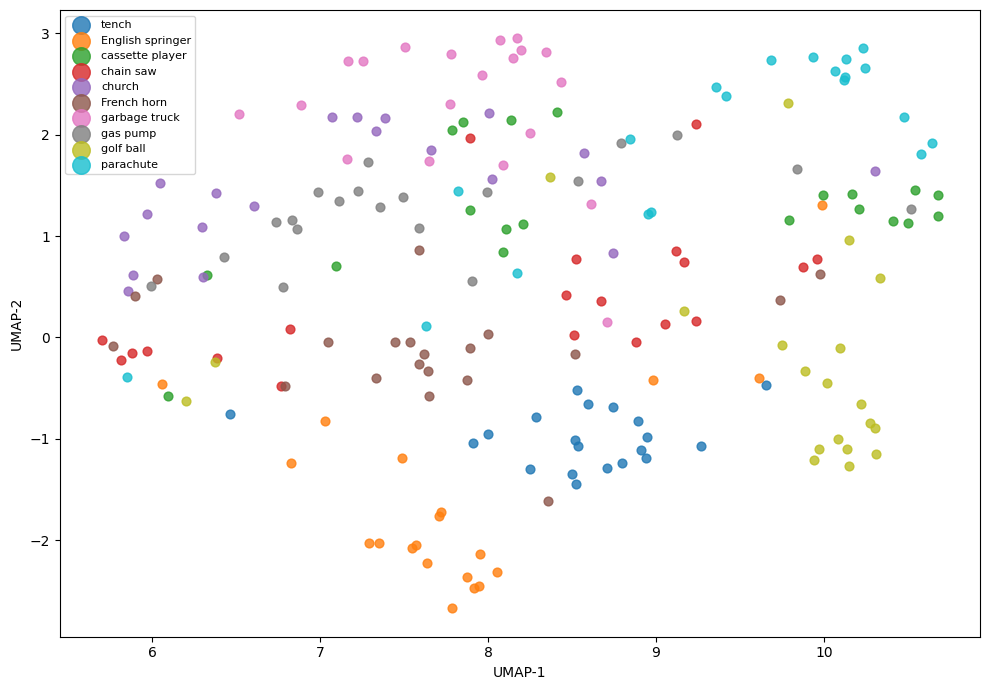

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
for class_idx in range(len(dataset.classes)):
    mask = all_labels_cls_m == class_idx
    ax.scatter(
        embedding_cls_m[mask, 0], embedding_cls_m[mask, 1],
        c=[CLASS_COLORS[class_idx]], s=40, alpha=0.8,
        label=class_names_list[class_idx]
    )

ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

---
## 8. Save

In [19]:
np.save("figures/all_z.npy",          all_z)
np.save("figures/all_labels.npy",     all_labels)
np.save("figures/all_patch_ids.npy",  all_patch_ids)
np.save("figures/embedding.npy",      embedding)
np.save("figures/all_z_cls.npy",      all_z_cls)
np.save("figures/embedding_cls.npy",  embedding_cls)

print("Tout sauvegardé dans figures/")

# Pour recharger sans réextraction :
# all_z         = np.load("figures/all_z.npy")
# all_labels    = np.load("figures/all_labels.npy")
# all_patch_ids = np.load("figures/all_patch_ids.npy")
# all_quadrants = patch_id_to_quadrant(all_patch_ids)
# embedding     = np.load("figures/embedding.npy")
# all_z_cls     = np.load("figures/all_z_cls.npy")
# embedding_cls = np.load("figures/embedding_cls.npy")

Tout sauvegardé dans figures/
